In [11]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(ROOT))

from src.paths import OUTPUT, FIG_OUTPUT

# 3.x, 4.x, 5.x, 6.0 Sequence and FC Models

In [12]:
# Helper function to load and filter metrics
MAIN_FEATURES = {"6F", "8F theta", "8F rho"}

def load_and_filter_metrics(path):
    """Load metrics CSV and keep only main feature rows + Analytic."""
    df = pd.read_csv(path)
    # Keep Analytic and the main feature combinations
    df_filtered = df[(df["Model"] == "Analytic") | (df["Model"].isin(MAIN_FEATURES))].copy()
    return df_filtered

# Load 3.x (LSTM) models
# 3.0: chro_A only
df_3_0_lstm_chro_A = load_and_filter_metrics(OUTPUT / "3.0-lstm-chro-A/01-run/chro_A/metrics_summary.csv")
df_3_0_lstm_chro_A["model"] = "3.0-LSTM"
df_3_0_lstm_chro_A["split"] = "A"

# 3.1: chro_B, chro_C, chro_D
dfs_3_1 = []
for split in ["B", "C", "D"]:
    df = load_and_filter_metrics(OUTPUT / f"3.1-lstm-chro-B-C-D/01-run/chro_{split}/metrics_summary.csv")
    df["model"] = "3.1-LSTM"
    df["split"] = split
    dfs_3_1.append(df)
df_3_1_lstm = pd.concat(dfs_3_1, ignore_index=True)

# Load 4.x (GRU) models
# 4.0: chro_A only
df_4_0_gru_chro_A = load_and_filter_metrics(OUTPUT / "4.0-gru-chro-A/01-run/chro_A/metrics_summary.csv")
df_4_0_gru_chro_A["model"] = "4.0-GRU"
df_4_0_gru_chro_A["split"] = "A"

# 4.1: chro_B, chro_C, chro_D
dfs_4_1 = []
for split in ["B", "C", "D"]:
    df = load_and_filter_metrics(OUTPUT / f"4.1-gru-chro-B-C-D/01-run/chro_{split}/metrics_summary.csv")
    df["model"] = "4.1-GRU"
    df["split"] = split
    dfs_4_1.append(df)
df_4_1_gru = pd.concat(dfs_4_1, ignore_index=True)

# Load 5.x (TFT) models
# 5.0: chro_A only
df_5_0_tft_chro_A = load_and_filter_metrics(OUTPUT / "5.0-tft-chro-A/01-run/chro_A/metrics_summary.csv")
df_5_0_tft_chro_A["model"] = "5.0-TFT"
df_5_0_tft_chro_A["split"] = "A"

# 5.1: chro_B, chro_C, chro_D
dfs_5_1 = []
for split in ["B", "C", "D"]:
    df = load_and_filter_metrics(OUTPUT / f"5.1-tft-chro-B-C-D/01-run/chro_{split}/metrics_summary.csv")
    df["model"] = "5.1-TFT"
    df["split"] = split
    dfs_5_1.append(df)
df_5_1_tft = pd.concat(dfs_5_1, ignore_index=True)

# Load 6.0 (FC) model - all splits A, B, C, D
dfs_6_0 = []
for split in ["A", "B", "C", "D"]:
    df = load_and_filter_metrics(OUTPUT / f"6.0-fc-chro-all/01-run/chro_{split}/metrics_summary.csv")
    df["model"] = "6.0-FC"
    df["split"] = split
    dfs_6_0.append(df)
df_6_0_fc = pd.concat(dfs_6_0, ignore_index=True)

# Combine all models
df_all = pd.concat([
    df_3_0_lstm_chro_A,
    df_3_1_lstm,
    df_4_0_gru_chro_A,
    df_4_1_gru,
    df_5_0_tft_chro_A,
    df_5_1_tft,
    df_6_0_fc,
], ignore_index=True)

In [13]:
# Restructure data: model type, feature, split as rows, all metrics as columns
df_final = df_all.copy()

# Extract model type (LSTM, GRU, TFT, FC) from model column
df_final["model"] = df_final["model"].str.extract(r"(LSTM|GRU|TFT|FC)")

# Rename Model to feature
df_final.rename(columns={"Model": "feature"}, inplace=True)

# Drop Gain_Incremental and unnecessary columns
metrics_to_keep = ["SSE", "MSE", "RMSE", "MAE", "MeanError", "MedianAE", "R2", "Training_time", "Gain_vs_Analytic"]
df_final = df_final[["model", "split", "feature"] + metrics_to_keep].copy()

# Filter out Analytic rows
df_final = df_final[df_final["feature"] != "Analytic"].copy()

# Reorder columns
col_order = ["model", "feature", "split"] + metrics_to_keep
df_final = df_final[col_order].reset_index(drop=True)

df_final.to_csv(FIG_OUTPUT / 'all-chro-modles.csv')
df_final

,model,feature,split,SSE,MSE,RMSE,MAE,MeanError,MedianAE,R2,Training_time,Gain_vs_Analytic
0,LSTM,6F,A,5.331666,0.000013,0.003538,0.001925,-0.000955,0.001227,0.690591,482.6s,62.11%
1,LSTM,8F theta,A,7.320460,0.000017,0.004145,0.002317,0.001023,0.001334,0.575176,195.9s,47.98%
2,LSTM,8F rho,A,5.672985,0.000013,0.003649,0.001961,-0.001101,0.001002,0.670783,689.7s,59.69%
3,LSTM,6F,B,1.792293,0.000012,0.003512,0.002246,-0.001149,0.001572,0.919658,360.7s,91.73%
4,LSTM,8F theta,B,1.959467,0.000013,0.003672,0.002159,-0.000396,0.001317,0.912164,216.6s,90.96%
5,LSTM,8F rho,B,1.917359,0.000013,0.003633,0.002011,-0.000809,0.001067,0.914052,263.8s,91.16%
6,LSTM,6F,C,2.194854,0.000012,0.003395,0.002028,-0.001241,0.001367,0.695549,290.2s,69.73%
7,LSTM,8F theta,C,11.085472,0.000058,0.007630,0.002895,-0.000460,0.001285,-0.537679,136.1s,-52.88%
8,LSTM,8F rho,C,1.470574,0.000008,0.002779,0.001876,-0.000939,0.001397,0.796015,236.8s,79.72%
9,LSTM,6F,D,4.602337,0.000043,0.006572,0.003571,0.000915,0.002197,0.147479,54.6s,8.09%


In [14]:
# ── Visualisation prep ────────────────────────────────────────────────────────
# Parse string fields and define shared constants for all presentation figures
# ─────────────────────────────────────────────────────────────────────────────
import seaborn as sns

df_viz = df_final.copy()
df_viz['Gain']    = df_viz['Gain_vs_Analytic'].str.rstrip('%').astype(float)
df_viz['Train_s'] = df_viz['Training_time'].str.rstrip('s').astype(float)

FEAT_SHORT = {
    '6F': '6F (γ)',
    '8F theta': '8F (θ)',
    '8F rho':   '8F (ρ)',
}
df_viz['feat'] = df_viz['feature'].map(FEAT_SHORT)
FEAT_COLS    = ['6F (γ)', '8F (θ)', '8F (ρ)']
MODEL_ORDER  = ['GRU', 'LSTM', 'TFT', 'FC']
MODEL_COLORS = {'GRU': '#2ca02c', 'LSTM': '#1f77b4', 'TFT': '#d62728', 'FC': '#9467bd'}

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['savefig.dpi'] = 150
print(f"Viz ready  ·  {len(df_viz)} rows  ·  models: {sorted(df_viz['model'].unique())}")
print(df_viz[['model','feat','split','R2','Gain','Train_s']].head(3))

Viz ready  ·  48 rows  ·  models: ['FC', 'GRU', 'LSTM', 'TFT']
  model    feat split        R2   Gain  Train_s
0  LSTM  6F (γ)     A  0.690591  62.11    482.6
1  LSTM  8F (θ)     A  0.575176  47.98    195.9
2  LSTM  8F (ρ)     A  0.670783  59.69    689.7


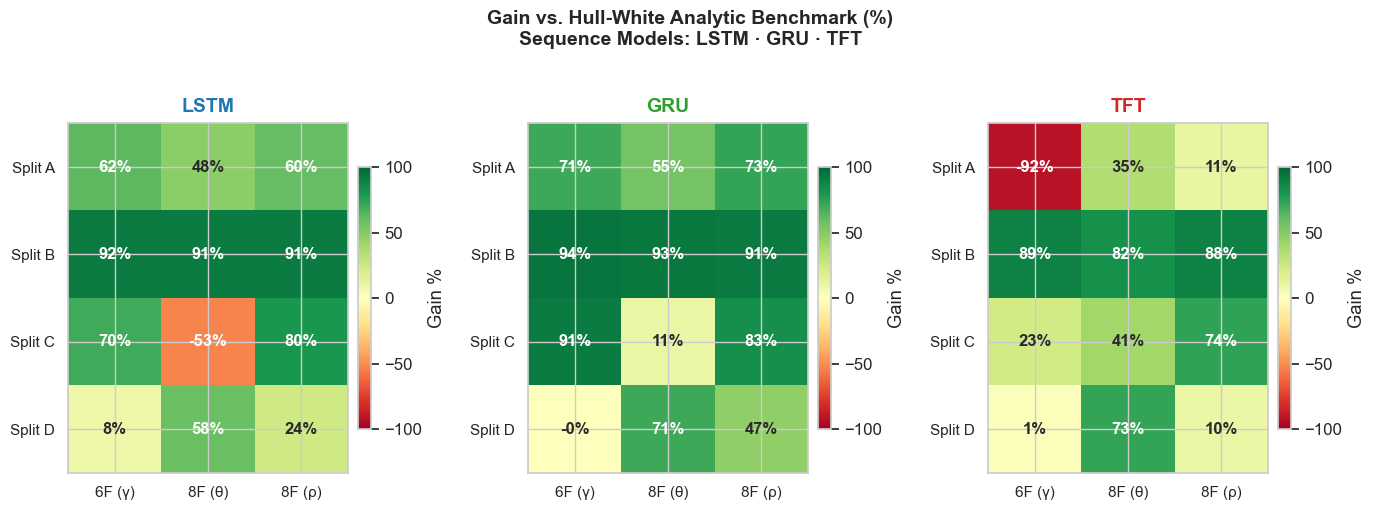

In [15]:

# ── Figure 1 ─────────────────────────────────────────────────────────────────
# Gain vs. Analytic (%) — annotated heatmap: rows = splits, cols = features
# One subplot per sequence model  (LSTM · GRU · TFT)
# ─────────────────────────────────────────────────────────────────────────────
SEQ   = ['LSTM', 'GRU', 'TFT']
CLIM  = 100

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, model in enumerate(SEQ):
    ax    = axes[i]
    sub   = df_viz[df_viz['model'] == model]
    pivot = (sub.pivot(index='split', columns='feat', values='Gain')
               .loc[list('ABCD'), FEAT_COLS])
    clipped = pivot.clip(-CLIM, CLIM)

    im = ax.imshow(clipped.values, cmap='RdYlGn', vmin=-CLIM, vmax=CLIM, aspect='auto')
    ax.set_xticks(range(3)); ax.set_xticklabels(FEAT_COLS, fontsize=11)
    ax.set_yticks(range(4)); ax.set_yticklabels([f'Split {s}' for s in 'ABCD'], fontsize=11)
    ax.tick_params(left=False, bottom=False)

    for r in range(4):
        for c in range(3):
            val = pivot.iloc[r, c]
            txt = 'white' if abs(clipped.iloc[r, c]) > 50 else '#2a2a2a'
            ax.text(c, r, f'{val:.0f}%', ha='center', va='center',
                    fontsize=12, color=txt, fontweight='bold')

    ax.set_title(model, fontsize=14, fontweight='bold',
                 color=MODEL_COLORS[model], pad=8)
    fig.colorbar(im, ax=ax, shrink=0.75, pad=0.03, label='Gain %')

fig.suptitle(
    'Gain vs. Hull-White Analytic Benchmark (%)\nSequence Models: LSTM · GRU · TFT',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
# plt.savefig(FIG_OUTPUT / 'pres_01_gain_heatmap_seq.pdf', bbox_inches='tight')
plt.show()


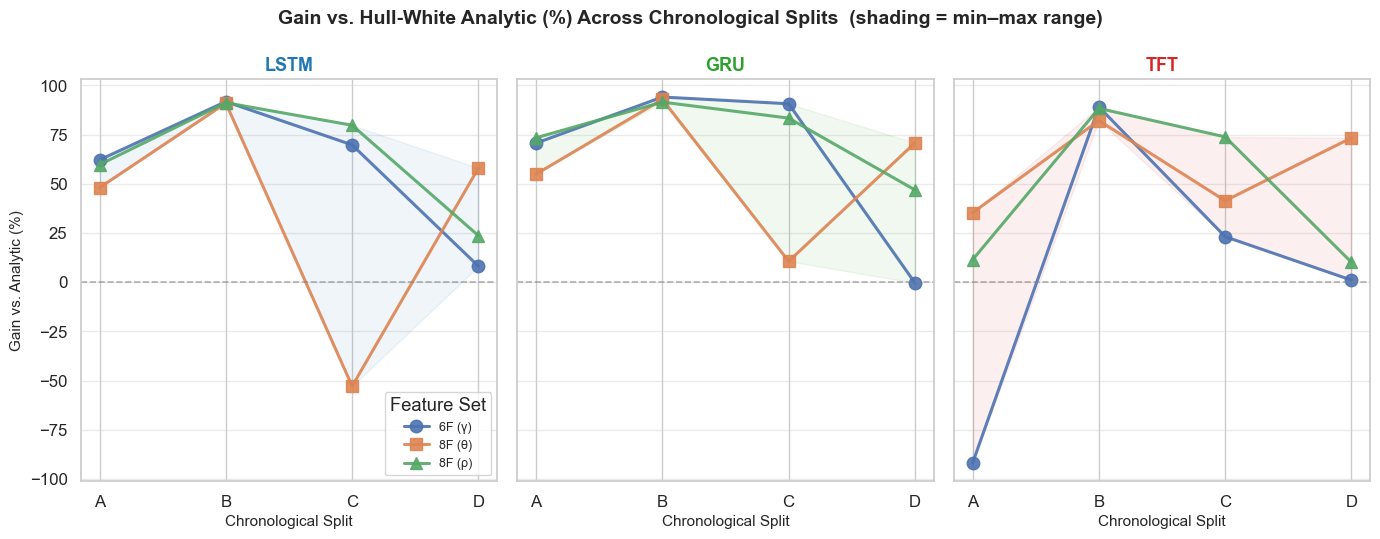

In [16]:

# ── Figure 2 ─────────────────────────────────────────────────────────────────
# Gain vs. Analytic (%) across chronological splits — line chart
# One subplot per model (LSTM · GRU · TFT); lines = feature sets
# Shows how stable/volatile each model is as the market regime shifts
# ─────────────────────────────────────────────────────────────────────────────
LINE_STYLES  = ['-o', '-s', '-^']
LINE_COLORS  = ['#4C72B0', '#DD8452', '#55A868']
SEQ          = ['LSTM', 'GRU', 'TFT']
SPLIT_LABELS = ['A', 'B', 'C', 'D']

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5), sharey=True)

for i, model in enumerate(SEQ):
    ax  = axes[i]
    sub = df_viz[df_viz['model'] == model]

    for j, feat in enumerate(FEAT_COLS):
        vals = [sub[(sub['split'] == s) & (sub['feat'] == feat)]['Gain'].values[0]
                for s in SPLIT_LABELS]
        ax.plot(SPLIT_LABELS, vals, LINE_STYLES[j],
                color=LINE_COLORS[j], lw=2.2, ms=9, label=feat, alpha=0.9)

    ax.axhline(0, color='grey', lw=1.2, ls='--', alpha=0.6)
    ax.fill_between(SPLIT_LABELS,
                    [sub[sub['split'] == s]['Gain'].min() for s in SPLIT_LABELS],
                    [sub[sub['split'] == s]['Gain'].max() for s in SPLIT_LABELS],
                    alpha=0.07, color=MODEL_COLORS[model])

    ax.set_title(model, fontsize=13, fontweight='bold', color=MODEL_COLORS[model])
    ax.set_xlabel('Chronological Split', fontsize=11)
    ax.yaxis.grid(True, alpha=0.4); ax.set_axisbelow(True)
    if i == 0:
        ax.set_ylabel('Gain vs. Analytic (%)', fontsize=11)
        ax.legend(title='Feature Set', fontsize=9, loc='lower right')

fig.suptitle('Gain vs. Hull-White Analytic (%) Across Chronological Splits  '
             '(shading = min–max range)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig(FIG_OUTPUT / 'pres_02_gain_by_split.pdf', bbox_inches='tight')
plt.show()


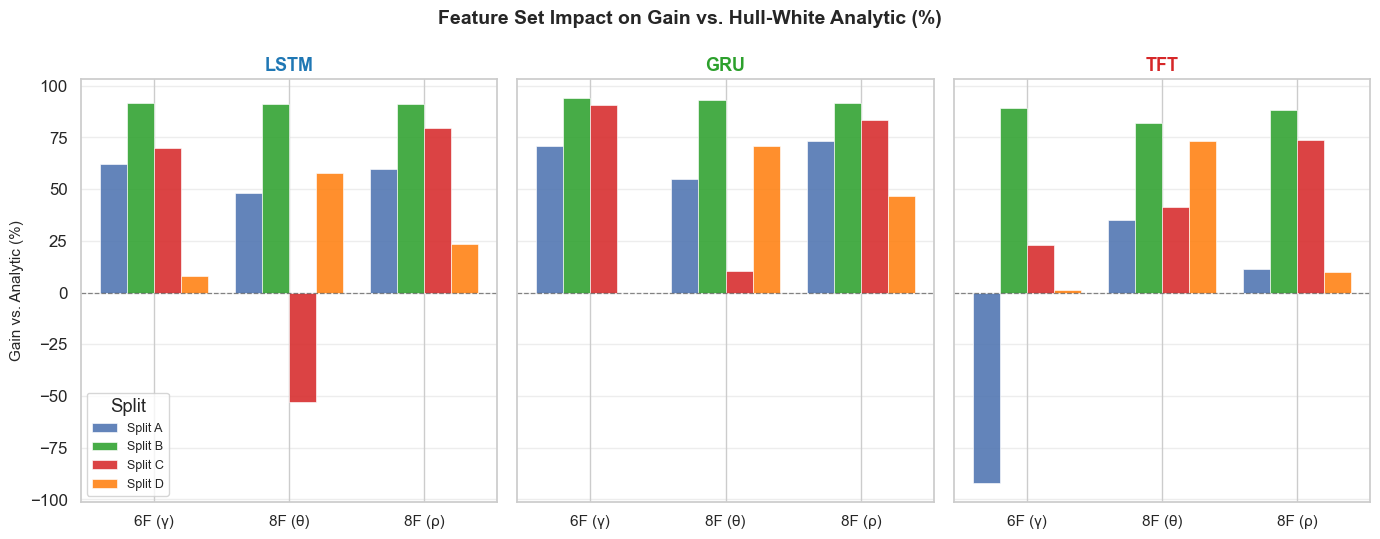

In [17]:

# ── Figure 3 ─────────────────────────────────────────────────────────────────
# Feature set impact on Gain vs. Analytic (%)
# Grouped bars: x = feature set, groups = splits A–D
# One subplot per model (LSTM · GRU · TFT)
# ─────────────────────────────────────────────────────────────────────────────
SPLIT_COLORS = {'A': '#4C72B0', 'B': '#2ca02c', 'C': '#d62728', 'D': '#ff7f0e'}
bar_w, x = 0.2, np.arange(3)
SEQ = ['LSTM', 'GRU', 'TFT']

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5), sharey=True)

for i, model in enumerate(SEQ):
    ax  = axes[i]
    sub = df_viz[df_viz['model'] == model]

    for j, split in enumerate('ABCD'):
        vals = [sub[(sub['split'] == split) & (sub['feat'] == f)]['Gain'].values[0]
                for f in FEAT_COLS]
        ax.bar(x + (j - 1.5) * bar_w, vals, bar_w,
               label=f'Split {split}', color=SPLIT_COLORS[split],
               alpha=0.87, edgecolor='white', lw=0.5)

    ax.axhline(0, color='black', lw=0.9, ls='--', alpha=0.45)
    ax.set_xticks(x); ax.set_xticklabels(FEAT_COLS, fontsize=11)
    ax.set_title(model, fontsize=13, fontweight='bold', color=MODEL_COLORS[model])
    ax.yaxis.grid(True, alpha=0.35); ax.set_axisbelow(True)
    if i == 0:
        ax.set_ylabel('Gain vs. Analytic (%)', fontsize=11)
        ax.legend(title='Split', fontsize=9)

fig.suptitle('Feature Set Impact on Gain vs. Hull-White Analytic (%)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig(FIG_OUTPUT / 'pres_03_gain_by_feature.pdf', bbox_inches='tight')
plt.show()


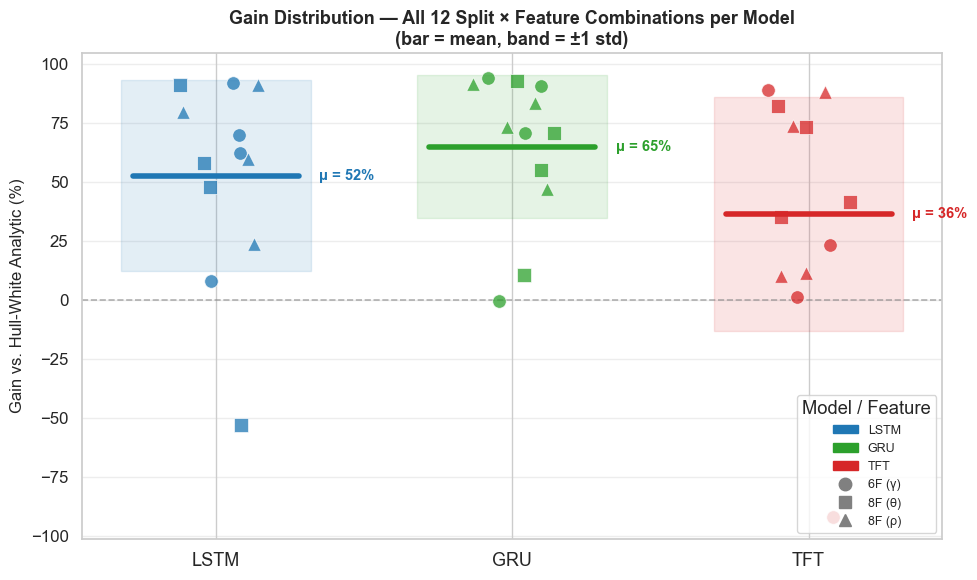

In [18]:

# ── Figure 4 ─────────────────────────────────────────────────────────────────
# Gain distribution — all 12 (split × feature) combos per model
# Dots = individual results, marker shape = feature set
# Horizontal bar = model mean; shaded band = ±1 std
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.lines  as mlines
import matplotlib.patches as mpatches

SEQ          = ['LSTM', 'GRU', 'TFT']
FEAT_MARKERS = {'6F (γ)': 'o', '8F (θ)': 's', '8F (ρ)': '^'}
rng          = np.random.default_rng(42)

fig, ax = plt.subplots(figsize=(10, 6))

for i, model in enumerate(SEQ):
    sub   = df_viz[df_viz['model'] == model]
    xpos  = i + 1
    gains = sub['Gain'].values
    mean_g, std_g = gains.mean(), gains.std()

    # ±1 std band
    ax.fill_between([xpos - 0.32, xpos + 0.32],
                    mean_g - std_g, mean_g + std_g,
                    color=MODEL_COLORS[model], alpha=0.12)

    # individual points
    for _, row in sub.iterrows():
        jitter = rng.uniform(-0.15, 0.15)
        ax.scatter(xpos + jitter, row['Gain'],
                   s=95, color=MODEL_COLORS[model], alpha=0.75,
                   marker=FEAT_MARKERS[row['feat']],
                   edgecolors='white', lw=0.6, zorder=3)

    # mean bar
    ax.plot([xpos - 0.28, xpos + 0.28], [mean_g, mean_g],
            color=MODEL_COLORS[model], lw=4, solid_capstyle='round', zorder=4)
    ax.text(xpos + 0.35, mean_g, f'μ = {mean_g:.0f}%',
            va='center', fontsize=10.5, color=MODEL_COLORS[model], fontweight='bold')

ax.axhline(0, color='grey', lw=1.2, ls='--', alpha=0.6, label='Hull-White (0%)')

model_patches = [mpatches.Patch(color=MODEL_COLORS[m], label=m) for m in SEQ]
feat_handles  = [mlines.Line2D([], [], color='grey', marker=v, lw=0, ms=9, label=k)
                 for k, v in FEAT_MARKERS.items()]
ax.legend(handles=model_patches + feat_handles,
          title='Model / Feature', fontsize=9, loc='lower right')

ax.set_xticks([1, 2, 3]); ax.set_xticklabels(SEQ, fontsize=13)
ax.set_ylabel('Gain vs. Hull-White Analytic (%)', fontsize=12)
ax.set_title('Gain Distribution — All 12 Split × Feature Combinations per Model\n'
             '(bar = mean, band = ±1 std)', fontsize=13, fontweight='bold')
ax.yaxis.grid(True, alpha=0.35); ax.set_axisbelow(True)

plt.tight_layout()
# plt.savefig(FIG_OUTPUT / 'pres_04_gain_distribution.pdf', bbox_inches='tight')
plt.show()


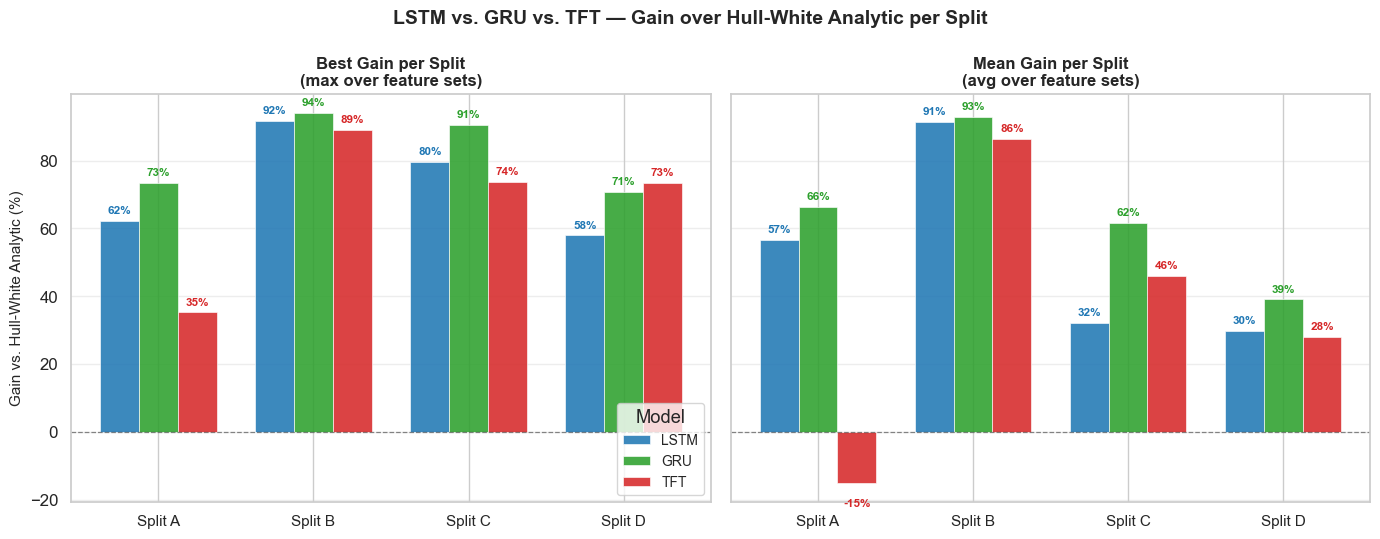

In [19]:

# ── Figure 5 ─────────────────────────────────────────────────────────────────
# Per-split head-to-head: best Gain (left) and mean Gain (right)
# LSTM vs. GRU vs. TFT — shows which model dominates each time period
# ─────────────────────────────────────────────────────────────────────────────
SEQ   = ['LSTM', 'GRU', 'TFT']
x, bw = np.arange(4), 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
configs = [
    ('Best Gain per Split\n(max over feature sets)', 'max'),
    ('Mean Gain per Split\n(avg over feature sets)',  'mean'),
]

for ax, (title, agg) in zip(axes, configs):
    for j, model in enumerate(SEQ):
        sub  = df_viz[df_viz['model'] == model]
        vals = [getattr(sub[sub['split'] == s]['Gain'], agg)() for s in 'ABCD']
        bars = ax.bar(x + (j - 1) * bw, vals, bw,
                      label=model, color=MODEL_COLORS[model],
                      alpha=0.87, edgecolor='white', lw=0.5)
        for bar, v in zip(bars, vals):
            yoff = 1.5 if v >= 0 else -4.5
            va   = 'bottom' if v >= 0 else 'top'
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + yoff, f'{v:.0f}%',
                    ha='center', va=va, fontsize=8.5,
                    color=MODEL_COLORS[model], fontweight='bold')

    ax.axhline(0, color='black', lw=0.9, ls='--', alpha=0.45)
    ax.set_xticks(x); ax.set_xticklabels([f'Split {s}' for s in 'ABCD'], fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.yaxis.grid(True, alpha=0.35); ax.set_axisbelow(True)
    if ax is axes[0]:
        ax.set_ylabel('Gain vs. Hull-White Analytic (%)', fontsize=11)
        ax.legend(title='Model', fontsize=10, loc='lower right')

fig.suptitle('LSTM vs. GRU vs. TFT — Gain over Hull-White Analytic per Split',
             fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig(FIG_OUTPUT / 'pres_05_gain_headtohead.pdf', bbox_inches='tight')
plt.show()


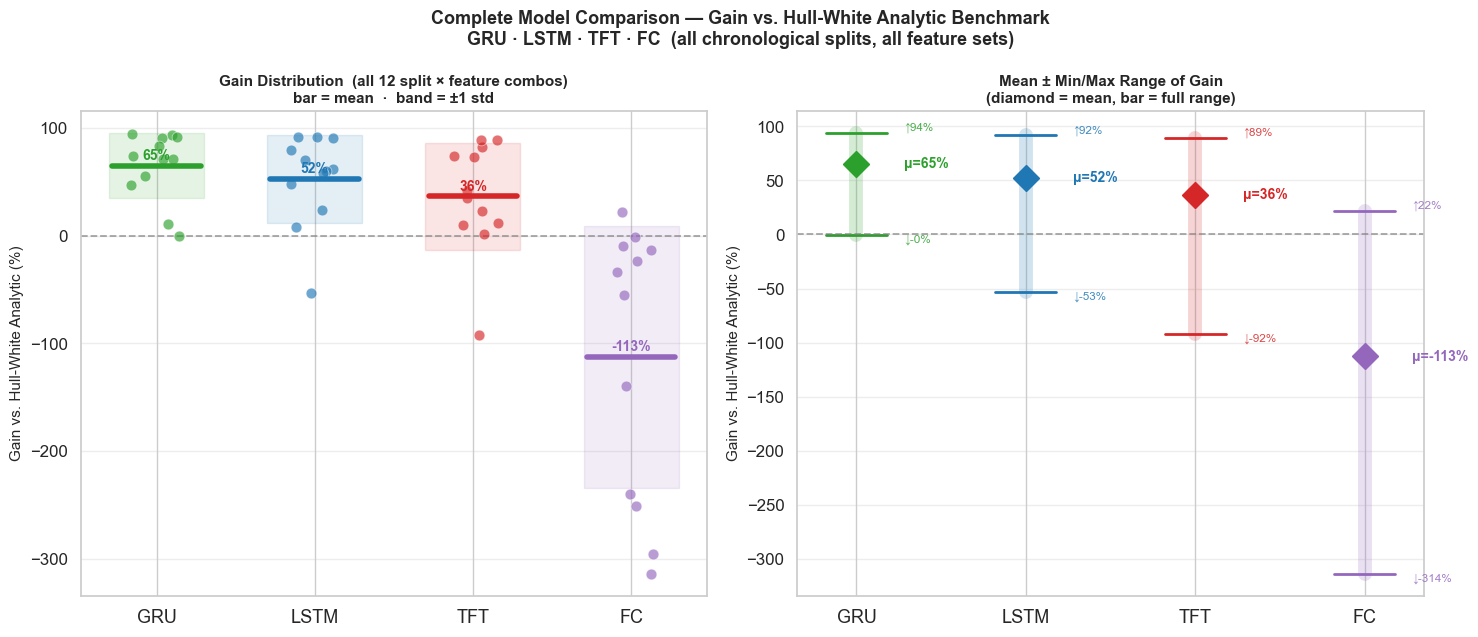

In [20]:

# ── Figure 6 — ALL 4 MODELS ───────────────────────────────────────────────────
# Complete comparison including FC (Fully-Connected baseline)
#
# Left:  All 12 (split × feature) Gain values per model with jittered dots
#        + mean bar + ±1 std band — FC's collapse clearly visible
# Right: Mean ± full range (min–max) lollipop chart — highlights how wide
#        FC's variance is compared with the consistent sequence models
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.lines  as mlines
import matplotlib.patches as mpatches

rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# ── Left: strip + mean bar + std band ────────────────────────────────────────
ax1 = axes[0]
for i, model in enumerate(MODEL_ORDER):
    sub    = df_viz[df_viz['model'] == model]
    xpos   = i + 1
    gains  = sub['Gain'].values
    mean_g = gains.mean()
    std_g  = gains.std()

    ax1.fill_between([xpos - 0.3, xpos + 0.3],
                     mean_g - std_g, mean_g + std_g,
                     color=MODEL_COLORS[model], alpha=0.12)

    for g in gains:
        ax1.scatter(xpos + rng.uniform(-0.16, 0.16), g,
                    s=60, color=MODEL_COLORS[model], alpha=0.65,
                    edgecolors='white', lw=0.5, zorder=3)

    ax1.plot([xpos - 0.28, xpos + 0.28], [mean_g, mean_g],
             color=MODEL_COLORS[model], lw=4, solid_capstyle='round', zorder=4)
    ax1.text(xpos, mean_g + 5.5, f'{mean_g:.0f}%',
             ha='center', fontsize=10, color=MODEL_COLORS[model], fontweight='bold')

ax1.axhline(0, color='grey', lw=1.3, ls='--', alpha=0.7)
ax1.set_xticks(range(1, 5)); ax1.set_xticklabels(MODEL_ORDER, fontsize=13)
ax1.set_ylabel('Gain vs. Hull-White Analytic (%)', fontsize=11)
ax1.set_title('Gain Distribution  (all 12 split × feature combos)\nbar = mean  ·  band = ±1 std',
              fontsize=11, fontweight='bold')
ax1.yaxis.grid(True, alpha=0.35); ax1.set_axisbelow(True)

# ── Right: lollipop — mean ± min/max range ────────────────────────────────────
ax2 = axes[1]
for i, model in enumerate(MODEL_ORDER):
    sub    = df_viz[df_viz['model'] == model]
    xpos   = i + 1
    mean_g = sub['Gain'].mean()
    max_g  = sub['Gain'].max()
    min_g  = sub['Gain'].min()

    # range stem
    ax2.plot([xpos, xpos], [min_g, max_g],
             color=MODEL_COLORS[model], lw=10, alpha=0.20,
             solid_capstyle='round')
    # min/max caps
    ax2.plot([xpos - 0.18, xpos + 0.18], [max_g, max_g],
             color=MODEL_COLORS[model], lw=2)
    ax2.plot([xpos - 0.18, xpos + 0.18], [min_g, min_g],
             color=MODEL_COLORS[model], lw=2)
    # mean diamond
    ax2.plot(xpos, mean_g, 'D', color=MODEL_COLORS[model], ms=13, zorder=5)
    # labels
    ax2.text(xpos + 0.28, mean_g,  f'μ={mean_g:.0f}%', va='center', fontsize=10,
             color=MODEL_COLORS[model], fontweight='bold')
    ax2.text(xpos + 0.28, max_g,   f'↑{max_g:.0f}%',   va='bottom', fontsize=8.5,
             color=MODEL_COLORS[model], alpha=0.85)
    ax2.text(xpos + 0.28, min_g,   f'↓{min_g:.0f}%',   va='top',    fontsize=8.5,
             color=MODEL_COLORS[model], alpha=0.85)

ax2.axhline(0, color='grey', lw=1.3, ls='--', alpha=0.7)
ax2.set_xticks(range(1, 5)); ax2.set_xticklabels(MODEL_ORDER, fontsize=13)
ax2.set_ylabel('Gain vs. Hull-White Analytic (%)', fontsize=11)
ax2.set_title('Mean ± Min/Max Range of Gain\n(diamond = mean, bar = full range)',
              fontsize=11, fontweight='bold')
ax2.yaxis.grid(True, alpha=0.35); ax2.set_axisbelow(True)

fig.suptitle('Complete Model Comparison — Gain vs. Hull-White Analytic Benchmark\n'
             'GRU · LSTM · TFT · FC  (all chronological splits, all feature sets)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig(FIG_OUTPUT / 'pres_06_all_models_gain.pdf', bbox_inches='tight')
plt.show()
